In [5]:
%pip install seaborn
%pip install xlrd


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\visha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\visha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [56]:
# This will correctly parse the binary .xls file
df = pd.read_excel('Concrete_Data.xls')

In [57]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)        1030 

In [59]:
df.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='str')

In [60]:
df.shape

(1030, 9)

In [61]:
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [62]:
df['Age (day)'].unique()

array([ 28, 270, 365, 360,  90, 180,   3,   7,  56,  91,  14, 100, 120,
         1])

# To Understand Data Distribution

# Histogram shows whether the data is:

# * Normal distribution

# * Left skewed

# * Right skewed

# * Uniform

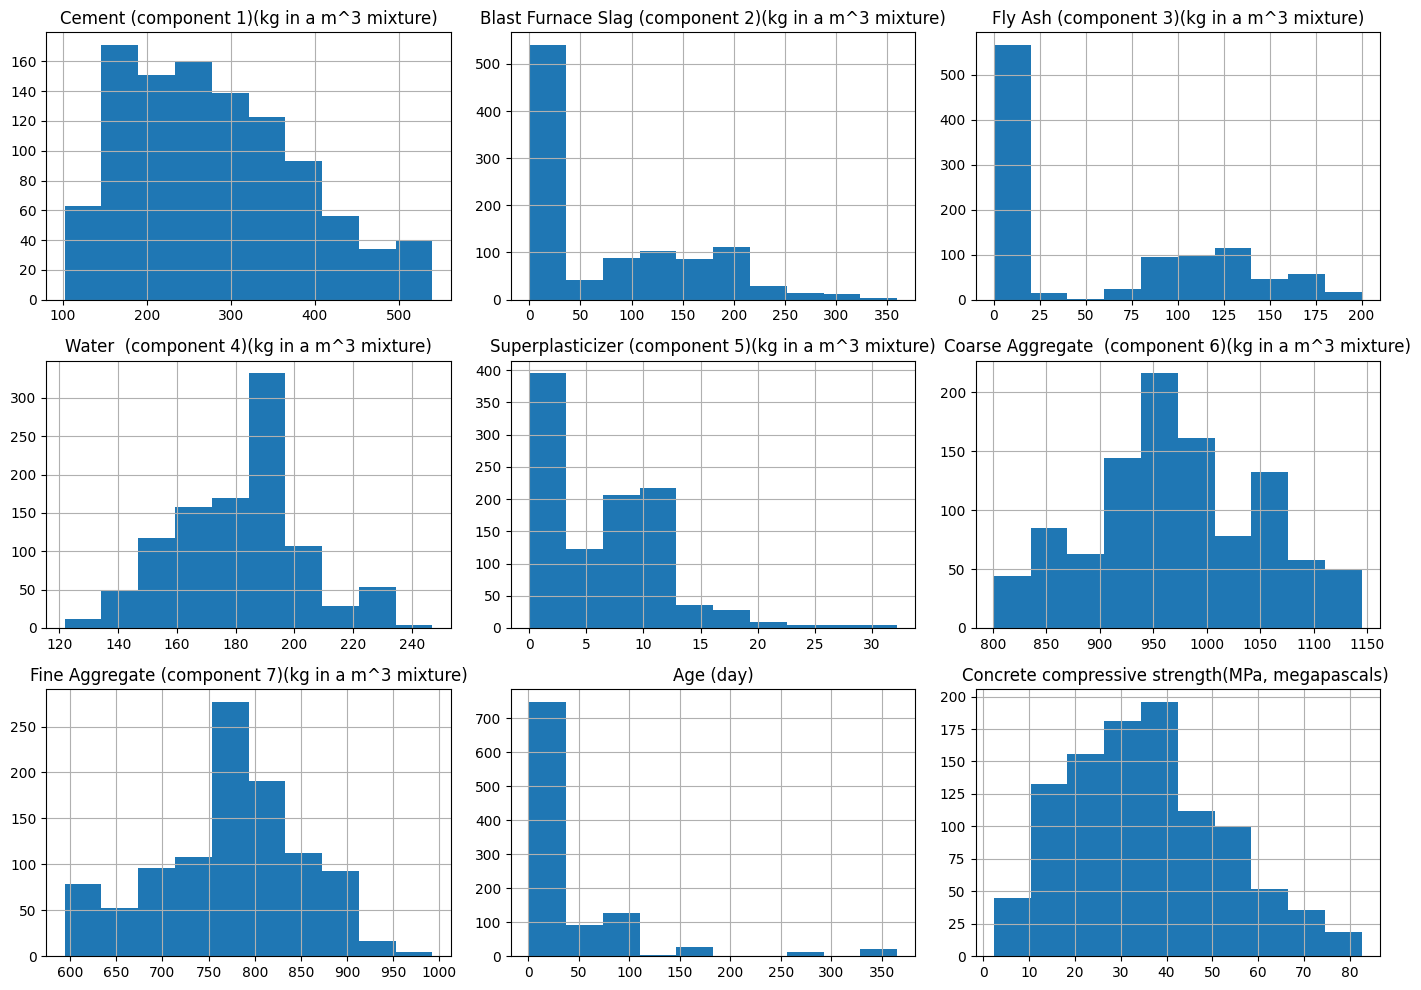

In [63]:
df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

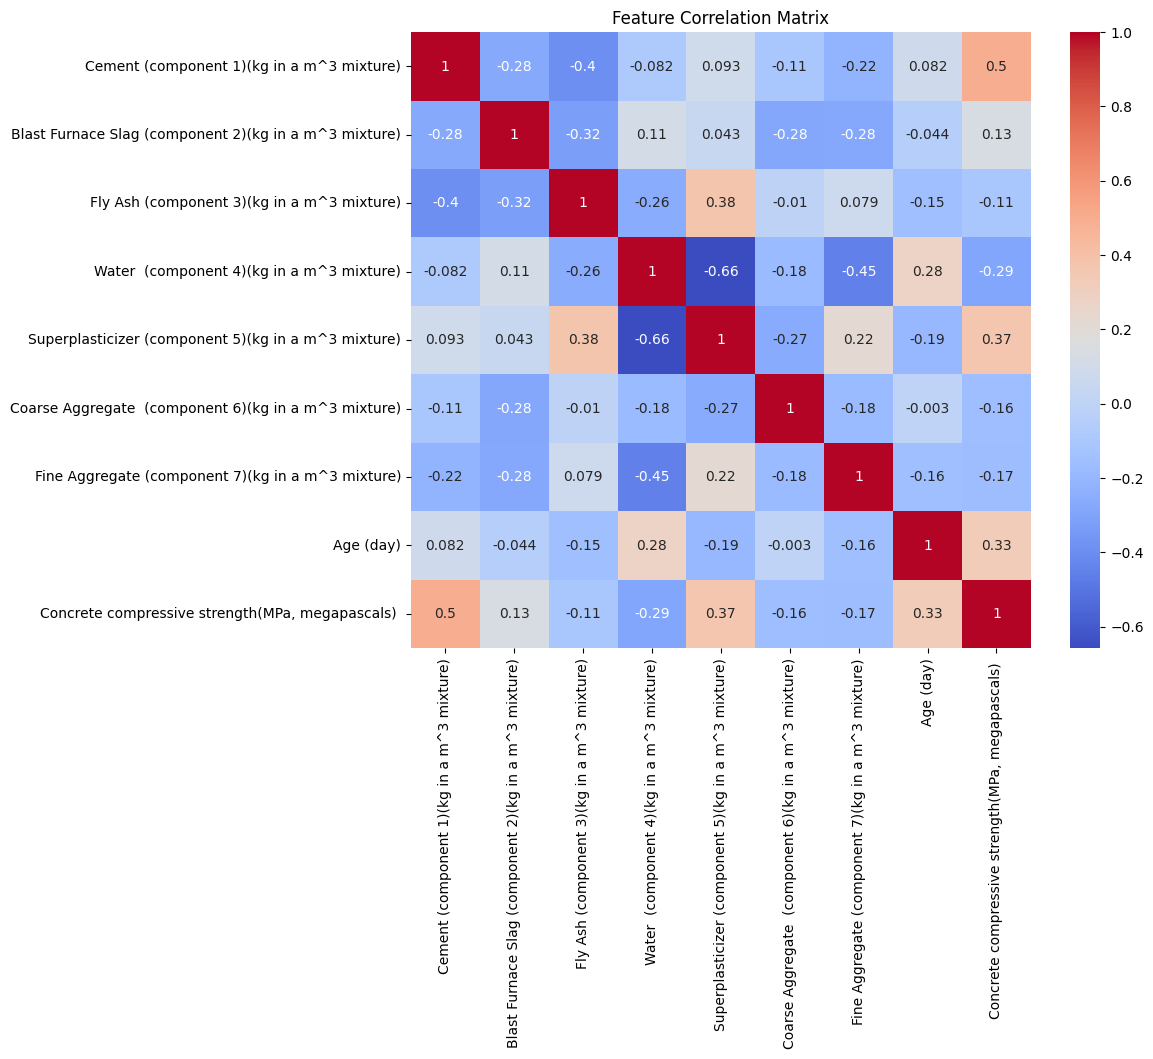

In [64]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

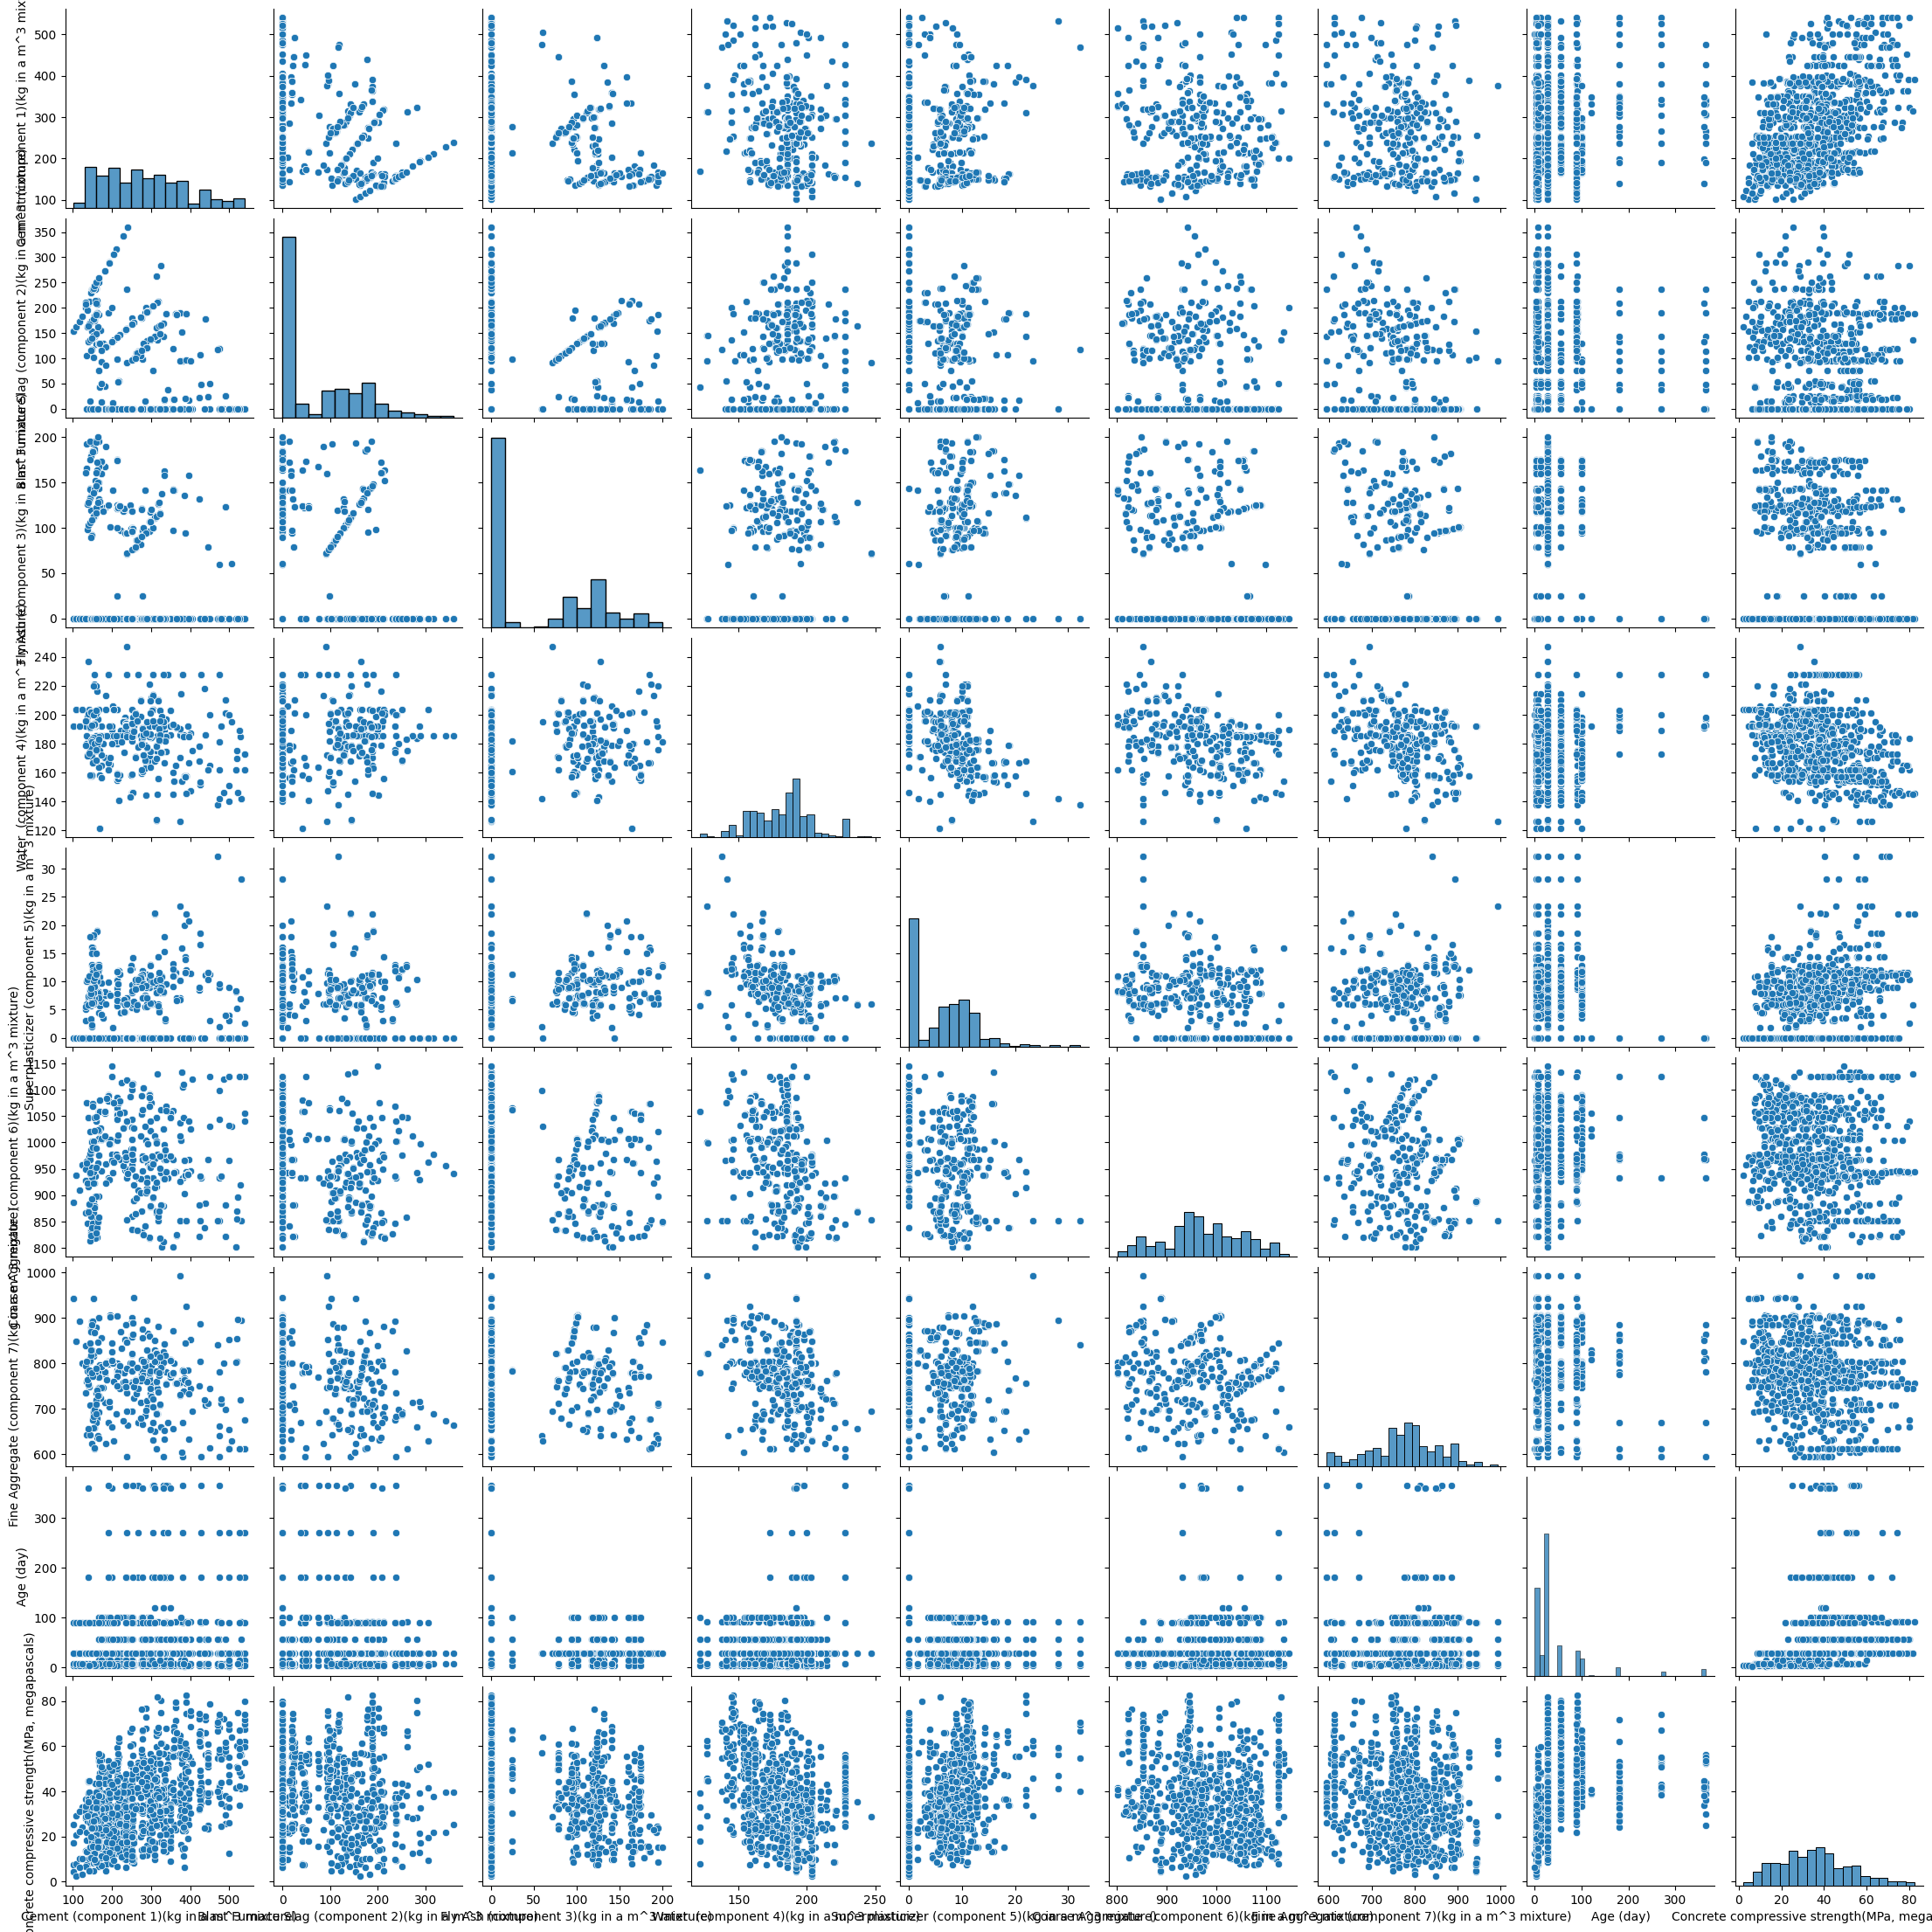

In [65]:
# This shows relationships between all features.

# For example:
# Cement vs Strength
# Age vs Strength
# Water vs Strength


sns.pairplot(df)
plt.show()

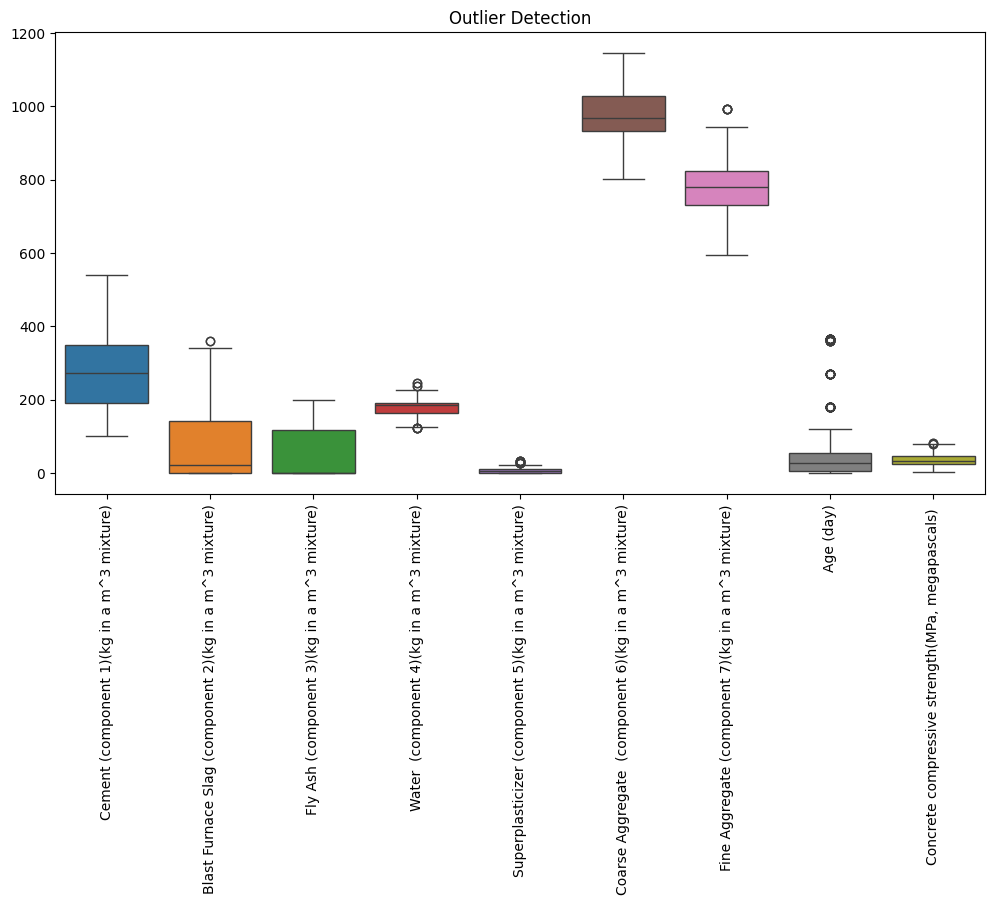

In [66]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Outlier Detection")

plt.show()

In [67]:
df.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='str')

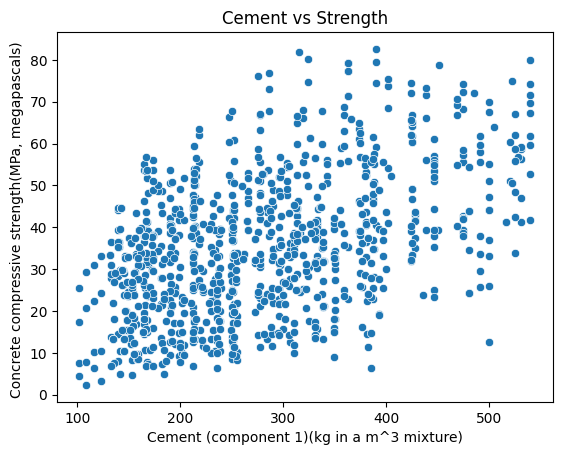

In [68]:
# here cheaking relation between cement vs strength 
sns.scatterplot(
    x=df['Cement (component 1)(kg in a m^3 mixture)'],
    y=df['Concrete compressive strength(MPa, megapascals) ']
)

plt.title("Cement vs Strength")

plt.show()

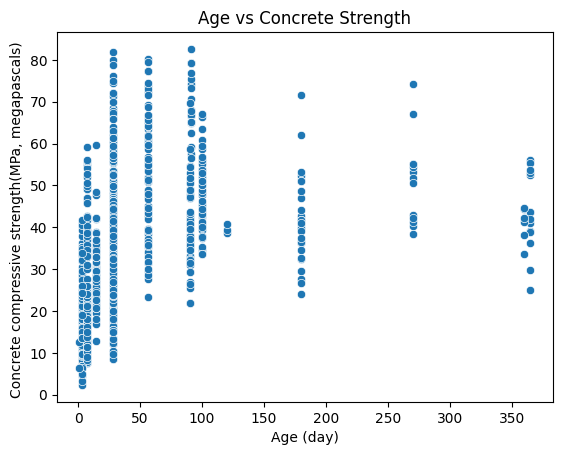

In [69]:
# here cheaking relation between cement vs strength 
sns.scatterplot(
    x=df['Age (day)'],
    y=df['Concrete compressive strength(MPa, megapascals) ']
)

plt.title("Age vs Concrete Strength")

plt.show()

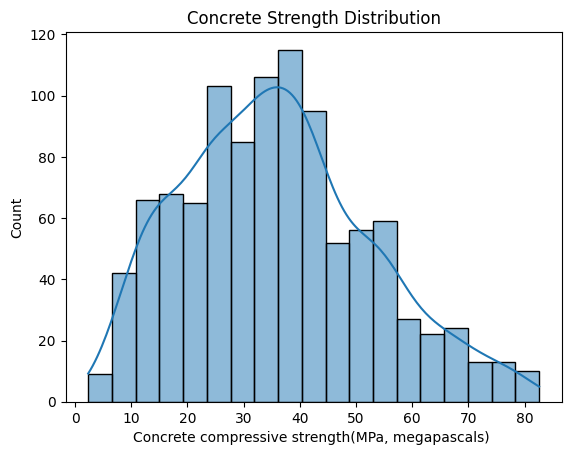

In [70]:
# distrubute direct varialbe
sns.histplot(
    df['Concrete compressive strength(MPa, megapascals) '],
    kde=True
)

plt.title("Concrete Strength Distribution")

plt.show()

In [71]:
# colume has big name so can change it 
df.columns = [
"Cement",
"BlastFurnaceSlag",
"FlyAsh",
"Water",
"Superplasticizer",
"CoarseAggregate",
"FineAggregate",
"Age",
"Strength"
]

df.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [72]:
# so we have some outlier through IQR we can handle it

# Q1 = df.quantile(0.25)
# Q3 = df.quantile(0.75)

# IQR = Q3- Q1
# # print(IQR)

# # DEFINING LOWER AND UPPER CASE
# lower_limit = Q1- IQR*1.5
# higher_limit = Q3 + IQR*1.5

# # REMOVE OUTLIERS
# df_clean = df[( (df< lower_limit) | (df> higher_limit)).any(axis=1)]
# print("Original Shape:", df.shape)
# print("After Removing Outliers:", df_clean.shape)

# Calculate IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

# Define limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Remove outliers
df_clean = df[~((df < lower_limit) | (df > upper_limit)).any(axis=1)]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (1030, 9)
After Removing Outliers: (941, 9)


In [73]:
df_clean.columns

Index(['Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water', 'Superplasticizer',
       'CoarseAggregate', 'FineAggregate', 'Age', 'Strength'],
      dtype='str')

# feature scalling 

In [25]:
X = df_clean.drop('Strength', axis=1)
y = df_clean['Strength']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Build Machine Learning Models

Simple Linear Regressions

Multi LinearRegression 

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()

model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

# Model Evaluation

In [27]:
print("R2 Score:", r2_score(y_test, y_pred_multi))

print("MAE:", mean_absolute_error(y_test, y_pred_multi))

print("MSE:", mean_squared_error(y_test, y_pred_multi))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_multi)))

print("\nModel Coefficients:", model_multi.coef_)
print("Intercept:", model_multi.intercept_)

R2 Score: 0.7415494879194751
MAE: 6.4014312864346
MSE: 67.1906287729606
RMSE: 8.196989006517002

Model Coefficients: [10.13578107  6.28720607  2.9997782  -5.14084288  0.53917367 -1.11541744
 -0.91149856  9.04024799]
Intercept: 34.82956948630464


# Visualization (Very Important)

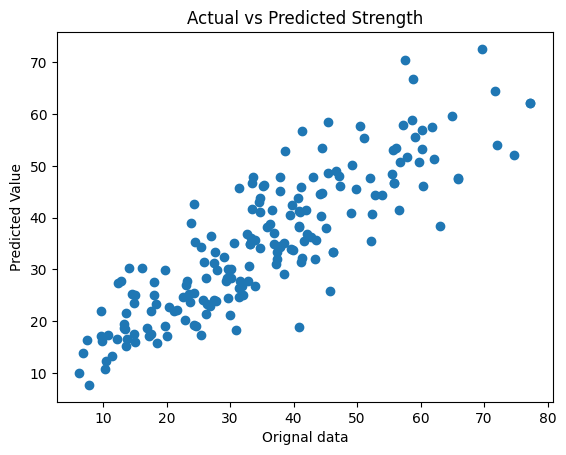

In [28]:
plt.scatter(y_test, y_pred_multi)
plt.xlabel("Orignal data")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted Strength")

plt.show()

In [29]:
plt.scatter(y_test, prede)

# best fit / perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted Strength")

plt.show()

NameError: name 'prede' is not defined

# save the model name with conrete_strength_model.

In [ ]:
import joblib

joblib.dump(model_multi, "concrete_strength_model.pkl")

['concrete_strength_model.pkl']

In [ ]:
import joblib

loaded_model = joblib.load("concrete_strength_model.pkl")

In [ ]:
prede= loaded_model.predict(X_test)

In [ ]:
print(prede)

[46.05172896 34.3431063  47.93724557 19.04320612 30.58867224 27.42662325
 43.8254054  24.77717481 21.40214118 21.90913311 36.19499704 35.44028927
 46.20713245 46.62068114 17.07873632 58.56748461 62.17367808 41.52033534
 25.15525829 18.62237978 34.17512905 21.27058933 25.48254227 25.141316
 48.14183166 42.3751269  34.96718281 33.34964    40.23425649 23.69884739
 20.16527977 50.79794077 52.14405418 28.33902151 28.35230949 47.76332763
 29.84885586 66.69895597 38.31343616 36.03815071 38.22130883 59.66830215
 17.40199417 43.76657837 25.81498088 19.39223677 19.25363987 32.14213539
 31.97884843 36.78141295 34.89715262 53.10732265 40.79678296 26.46776023
 16.62204397 44.6896597  27.76300461 52.96623916 29.98003167 24.1063158
 44.28925071 21.95879464  9.91983149 46.65448871 37.92066152 15.87843599
 50.80019393 28.4274347  40.85704881 24.05307533 41.07004011 54.12034167
 31.95159322 18.29287595 36.47647581 22.17509614 23.41329705 46.09097496
 38.14445718 46.361512   41.19424983 31.50934403 22.89

# simple linear Regression 

In [84]:
X = df[['Cement']]
y = df['Strength']

In [85]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=47
)

Train Model

In [87]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [88]:
y_pred = model.predict(X_test)

C:\Users\visha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


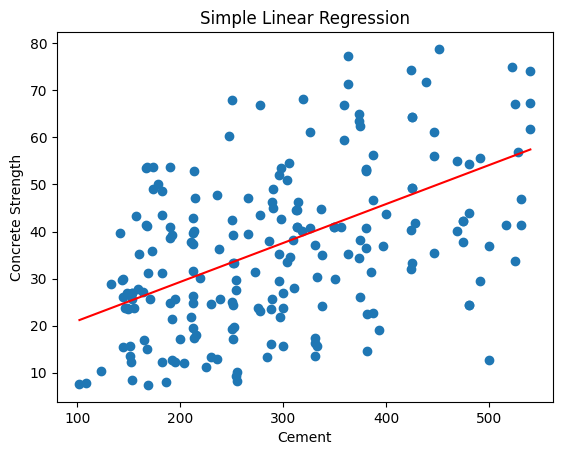

In [89]:


plt.scatter(X_test, y_test)

x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model.predict(x_line.reshape(-1,1))

plt.plot(x_line, y_line, color='red')

plt.xlabel("Cement")
plt.ylabel("Concrete Strength")

plt.title("Simple Linear Regression")

plt.show()

In [90]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.21007104946387645
MAE: 12.175858926622775
MSE: 220.38894232687312
RMSE: 14.845502427566172


# important
Your R² ≈ 0.21 (21%) is low because you are using Simple Linear Regression with only one variable (Cement).

Concrete strength does not depend only on Cement. It depends on many variables together.

In [ ]:
# important
